# Exploring emotional spaces
### PSYC3914 · Interactive tutorial

How can we map human emotions evoked by a picture? In this activity you will explore people's ratings, look for patterns, and build a map of emotional responses to learn about how humans encode the emotional content of images.

**You do not need to write or edit code.** Use the dropdowns and number boxes, then click the **▶ play button** beside the activity. The calculations are hidden; you can choose **Show code** if you want to inspect them.

### Before you begin
1. Save your own copy: **File → Save a copy in Drive**.
2. Click **Connect** near the top of the page if you are not already connected.
3. Start with **Load the tutorial dataset**, then work down the page in order. Wait for each activity to finish before continuing. **Avoid Run all on your first visit:** make your predictions before revealing results.
4. To explore a different choice, change its control and click its play button again. Write your answers in your class notes, or add a text cell to your own notebook copy.

The original analysis figures are saved PG examples. New challenge activities start without answers displayed. Run each challenge to see its options and controls, make a prediction, then reveal its results. Changes to options and controls take effect when you run that activity again.

**Content choice:** The images in this tutorial come from the International Affective Picture System (IAPS). [Read more about IAPS](https://imotions.com/blog/learning/research-fundamentals/iaps-international-affective-picture-system/). We have created a PG subset that excludes the disgust and erotic categories, but still includes fear and sadness imagery. Full includes potentially disturbing imagery and erotica. PG is the starting choice. You can complete the tutorial with either dataset.

The data downloads automatically. If your session disconnects or resets, reconnect and run the activities again from the start.

Original tutorial by the course author, with thanks to Brianna Kennedy, Tijl Grootswagers, and Dr Steven Most.

**Your investigation:** predict six pictures → uncover disagreement → test a component interpretation → change the stimulus sample → optionally compare your predictions with AI. Your predictions stay in this runtime unless you download them; they are not submitted to the lecturer.

## Part 1A · Get ready
People rated pictures on seven questions, using scales from 1 to 9:

| Question | What you are rating | A rating of 1 means… | A rating of 9 means… |
|---|---|---|---|
| Valence | How pleasant or unpleasant the picture makes you feel overall. | Very unhappy | Very happy |
| Arousal | How activated or excited the picture makes you feel, rather than calm. | Not at all aroused | Very aroused |
| Anger | How angry, irritated, or annoyed the picture makes you feel. | No anger | Very much anger |
| Sadness | How sad or sorrowful the picture makes you feel. | No sadness | Very much sadness |
| Fear | How frightened or threatened the picture makes you feel. | No fear | Very much fear |
| Disgust | How repulsed or revolted the picture makes you feel. | No disgust | Very much disgust |
| Happiness | How much happiness or joy the picture makes you feel. | No happiness | Very much happiness |

**Valence and happiness are related, but their scales differ:** valence runs from very unhappy through the middle to very happy; happiness asks how much happiness is present. A low happiness rating does not necessarily mean someone feels very unhappy. Here, **arousal** means emotional activation, not specifically sexual arousal.

**Do this:** Choose Full or PG below and click ▶. Wait for the message confirming that the pictures and ratings are ready.

If you choose a different dataset later, run this activity and all the following activities again.

In [ ]:
#@title Load the tutorial dataset { display-mode: "form" }
DATASET = "PG" #@param ["PG", "Full"]

# Dataset archives are hosted in the tutorial GitHub release.
# These URLs must return the ZIP bytes, not a sharing/preview web page.
DATA_URLS = {'PG': 'https://github.com/ThomasSydneyEDU/emotional-spaces-tutorial/releases/download/v1.0.0/emotionalspaces_pg.zip', 'Full': 'https://github.com/ThomasSydneyEDU/emotional-spaces-tutorial/releases/download/v1.0.0/emotionalspaces_full.zip'}
EXPECTED_SHA256 = {'PG': '96b8306d92dbd2357e56170fe09f81362d304f2f1e5be70b6af059ce886c4c05', 'Full': 'c40b587b06ec7fb58b249a3a4a9aeae8a627f0c6d56b1df32e9f7a240b15a2dd'}

from pathlib import Path
import hashlib, io, json, zipfile
from urllib.request import Request, urlopen
from urllib.parse import urlparse
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
if DATASET not in DATA_URLS:
    raise ValueError("Choose PG or Full.")
archive_name = f"emotionalspaces_{DATASET.lower()}.zip"
archive_path = Path(archive_name)
expected = EXPECTED_SHA256[DATASET]
if archive_path.exists() and hashlib.sha256(archive_path.read_bytes()).hexdigest() != expected:
    raise ValueError(f"{archive_name} does not match the supplied dataset. Remove it and rerun setup.")
if not archive_path.exists():
    url = DATA_URLS[DATASET].strip()
    if not url:
        raise RuntimeError("The lecturer has not configured this dataset's online link. "
                           "For a local preview, put its ZIP next to this notebook.")
    if urlparse(url).scheme != "https":
        raise ValueError("Use an HTTPS dataset URL.")
    print(f"Downloading the {DATASET} dataset…")
    request = Request(url, headers={"User-Agent": "EmotionalSpaces-Tutorial/1.0"})
    with urlopen(request, timeout=120) as response:
        payload = response.read()
    if hashlib.sha256(payload).hexdigest() != expected:
        raise ValueError("Download failed validation. Check that the URL returns the original ZIP, "
                         "not a login or preview page.")
    temporary_path = archive_path.with_suffix(".download")
    temporary_path.write_bytes(payload)
    temporary_path.replace(archive_path)
# Read from the archive directly; no extraction or executable data objects.
with zipfile.ZipFile(archive_path) as z:
    metadata = json.loads(z.read("metadata.json"))
    ratings = np.load(io.BytesIO(z.read("ratings.npy")), allow_pickle=False)
    image_bytes = [z.read(f"images/{i+1:03d}.png") for i in range(len(metadata["names"]))]
names = metadata["names"]
questions = metadata["questions"]
if (ratings.ndim != 3 or ratings.shape[1] != len(names)
        or ratings.shape[2] != len(questions) or ratings.shape[2] != 7):
    raise ValueError("Dataset dimensions do not match the image/question metadata.")
means = np.nanmean(ratings, axis=0)
if not np.isfinite(means).all():
    raise ValueError("An image/question has no finite mean rating.")
if not np.isfinite(ratings[~np.isnan(ratings)]).all():
    raise ValueError("Unexpected infinite responses.")

def image_at(image_number):
    if not isinstance(image_number, (int, np.integer)) or not 1 <= image_number <= len(names):
        raise ValueError(f"Image number must be between 1 and {len(names)}.")
    return np.array(Image.open(io.BytesIO(image_bytes[image_number - 1])))

def check_question(number):
    if not 1 <= number <= len(questions):
        raise ValueError(f"Question number must be between 1 and {len(questions)}.")
    return number - 1

print(f"Ready! The {DATASET} dataset contains {len(names)} pictures and {len(questions)} questions.")
print(f"Choose an image number from 1 to {len(names)} in the next activity.")

import re, csv, html, numbers
import ipywidgets as widgets
from IPython.display import display, HTML, FileLink
from scipy.optimize import linear_sum_assignment

# Fixed PG-compatible examples preserve picture identity between datasets.
challenge_names = ["pleasant26", "pleasant70", "fear11", "sad3", "neutral9", "extreme60"]
challenge_indices = [names.index(name) for name in challenge_names]
challenge_labels = [f"Picture {i+1}" for i in range(6)]
student_predictions = {}
ai_predictions = None
ai_run_metadata = {}
ai_comparison_snapshot = None

def validate_predictions(value, require_all=True):
    if not isinstance(value, dict):
        raise ValueError("Paste the JSON object containing Picture 1 through Picture 6.")
    if require_all and set(value) != set(challenge_labels):
        raise ValueError("Include exactly Picture 1 through Picture 6, once each.")
    if not set(value).issubset(set(challenge_labels)):
        raise ValueError("An unrecognized picture label was included.")
    clean = {}
    for label, row in value.items():
        if (not isinstance(row, list) or len(row) != 7 or
            any(isinstance(x, bool) or not isinstance(x, numbers.Real) for x in row)):
            raise ValueError(f"{label} needs seven numeric ratings in the specified question order.")
        values = np.asarray(row, dtype=float)
        if not np.isfinite(values).all() or np.any((values < 1) | (values > 9)):
            raise ValueError(f"{label}: every rating must be finite and between 1 and 9.")
        clean[label] = values.tolist()
    return clean

def decode_predictions(text, require_all=True):
    # Chat apps and word processors can substitute typographic double quotes.
    text = text.strip().translate(str.maketrans({"“": '"', "”": '"'}))
    if text.startswith("```"):
        lines = text.splitlines()
        if lines[-1].strip() != "```":
            raise ValueError("Copy the complete JSON response.")
        text = "\n".join(lines[1:-1])
    def unique_object(pairs):
        result = {}
        for key, value in pairs:
            if key in result:
                raise ValueError(f"Repeated picture label: {key}")
            result[key] = value
        return result
    try:
        value = json.loads(text, object_pairs_hook=unique_object)
    except json.JSONDecodeError as exc:
        raise ValueError("The pasted response is not valid JSON. Copy only the JSON object.") from exc
    return validate_predictions(value, require_all)

def download_file(path):
    try:
        from google.colab import files
    except ImportError:
        display(FileLink(str(path)))
    else:
        files.download(str(path))

def show_table(headers, rows):
    head = "".join("<th style='padding:8px;text-align:left'>" + html.escape(str(x)) + "</th>" for x in headers)
    body = "".join("<tr>" + "".join("<td style='padding:8px;border-top:1px solid #dde5eb'>" + html.escape(str(x)) + "</td>" for x in row) + "</tr>" for row in rows)
    display(HTML("<div style='overflow-x:auto'><table style='border-collapse:collapse'><thead><tr>" + head + "</tr></thead><tbody>" + body + "</tbody></table></div>"))

def comparison_plot(your_values, ai_values=None):
    human = means[challenge_indices]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        ax.plot(range(7), human[i], "o-", label="Participants' mean")
        ax.plot(range(7), your_values[i], "s--", label="Your prediction")
        if ai_values is not None:
            ax.plot(range(7), ai_values[i], "^:", label="AI prediction")
        ax.set(title=challenge_labels[i], ylim=(1, 9), ylabel="Rating")
        ax.set_xticks(range(7), questions, rotation=50, ha="right")
        ax.grid(axis="y", alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    plt.show()
    return human

def fit_pca(values):
    center = values.mean(axis=0)
    centered = values - center
    _, singular, vt = np.linalg.svd(centered, full_matrices=False)
    weights = vt.T.copy()
    scores = centered @ weights
    for c in range(weights.shape[1]):
        if weights[np.argmax(np.abs(weights[:, c])), c] < 0:
            weights[:, c] *= -1
            scores[:, c] *= -1
    latent = singular ** 2 / (len(values) - 1)
    return center, weights, scores, latent

def align_components(reference, weights, scores):
    # Match all components by absolute loading similarity, then align signs.
    similarity = reference.T @ weights
    rows, cols = linear_sum_assignment(-np.abs(similarity))
    order = cols[np.argsort(rows)]
    signs = np.sign(similarity[np.arange(len(order)), order])
    signs[signs == 0] = 1
    return weights[:, order] * signs, scores[:, order] * signs, order, np.abs(similarity[np.arange(len(order)), order])


## Investigation 1 · Predict before you peek
Before looking at the participants' results, predict the **average human rating** for six pictures. Use the same seven questions and 1–9 scales listed above. These are forecasts of the group average, rather than a test of your own emotional reactions.

Before looking at the participants' results, try to make a prediction for the **average human rating** for six pictures. For each picture, make your prediction for the seven questions and 1–9 scales. These are forecasts of the group average, rather than a test of your own emotional reactions.

**Commit first:** Record a short reason for one prediction in your notes. Which question do you think will be hardest to predict?

Save a backup with **Download my predictions**. If the runtime resets or you rerun the data-loading activity, use **Restore saved predictions** to paste the contents of that file back into this activity. Rerunning this activity alone retains saved predictions.

In [ ]:
#@title Make your six predictions { display-mode: "form" }
# Close old controls when rerunning, so there is only one active rating panel.
if "prediction_panel" in globals():
    prediction_panel.close()
picture_picker = widgets.Dropdown(options=challenge_labels, description="Picture:")
prediction_image = widgets.Image(format="png", width=320)
prediction_sliders = [widgets.FloatSlider(value=5, min=1, max=9, step=0.1, readout_format=".1f",
    description=q + ":", style={"description_width": "100px"},
    layout=widgets.Layout(width="440px"), continuous_update=False) for q in questions]
confirm_prediction = widgets.Checkbox(value=False, description="I have considered all seven ratings")
save_prediction_button = widgets.Button(description="Save this prediction", button_style="primary", layout=widgets.Layout(width="190px"))
export_predictions_button = widgets.Button(description="Download my predictions", layout=widgets.Layout(width="230px"))
restore_predictions_text = widgets.Textarea(placeholder="Paste the contents of my_predictions.json here to restore a backup", layout=widgets.Layout(width="100%", height="90px"))
restore_predictions_button = widgets.Button(description="Restore saved predictions", layout=widgets.Layout(width="230px"))
prediction_status = widgets.HTML()
prediction_messages = widgets.Output()

def refresh_prediction(change=None):
    label = picture_picker.value
    index = challenge_labels.index(label)
    prediction_image.value = image_bytes[challenge_indices[index]]
    saved = student_predictions.get(label, [5] * 7)
    for slider, value in zip(prediction_sliders, saved):
        slider.value = float(value)
    confirm_prediction.value = False
    prediction_status.value = f"<b>{len(student_predictions)} of 6 predictions saved.</b> Unsaved changes are lost when switching pictures."

def save_prediction(button=None):
    with prediction_messages:
        prediction_messages.clear_output()
        if not confirm_prediction.value:
            print("Consider all seven ratings, then tick the confirmation box before saving.")
            return
        student_predictions[picture_picker.value] = [s.value for s in prediction_sliders]
        prediction_status.value = f"<b>{len(student_predictions)} of 6 predictions saved.</b>"
        confirm_prediction.value = False
        print(f"Saved {picture_picker.value}. Choose another picture, or continue after all six are saved.")

def export_predictions(button=None):
    with prediction_messages:
        prediction_messages.clear_output()
        path = Path("my_predictions.json")
        path.write_text(json.dumps(student_predictions, indent=2))
        download_file(path)
        print("Keep this file to restore your predictions after a session reset.")

def restore_predictions(button=None):
    with prediction_messages:
        prediction_messages.clear_output()
        try:
            restored = decode_predictions(restore_predictions_text.value, require_all=False)
        except ValueError as exc:
            print(str(exc)); return
        student_predictions.update(restored)
        refresh_prediction()
        print(f"Restored {len(restored)} saved predictions.")

picture_picker.observe(refresh_prediction, names="value")
save_prediction_button.on_click(save_prediction)
export_predictions_button.on_click(export_predictions)
restore_predictions_button.on_click(restore_predictions)
refresh_prediction()
prediction_panel = widgets.VBox([picture_picker, prediction_image, *prediction_sliders,
    confirm_prediction, save_prediction_button, prediction_status,
    export_predictions_button, restore_predictions_text, restore_predictions_button,
    prediction_messages])
display(prediction_panel)

### Reveal · How close were your forecasts?
**Do this:** Once all six predictions are saved, run the comparison. Smaller differences mean your forecasts were closer to the participant averages for these examples; there are no right or wrong personal emotional reactions.

**Discuss:** Which question was hardest to predict? Which picture surprised you? Does a close match to the mean tell you whether participants agreed with one another?

The six pictures are selected teaching examples, not a representative test set. Keep your original forecasts unchanged for the AI comparison at the end.

In [ ]:
#@title Compare your predictions with the participants { display-mode: "form" }
if set(student_predictions) != set(challenge_labels):
    print(f"Save all six predictions first. Currently saved: {len(student_predictions)} of 6.")
else:
    your_values = np.asarray([student_predictions[label] for label in challenge_labels])
    human_values = comparison_plot(your_values)
    differences = np.abs(your_values - human_values)
    show_table(["Picture", "Mean absolute difference (rating points)"],
               [[label, f"{differences[i].mean():.2f}"] for i, label in enumerate(challenge_labels)])
    print(f"Across these six pictures: {differences.mean():.2f} rating points average absolute difference.")

## Part 1B · How do people respond to a picture?
**Do this:** Start with image 1 and click ▶. You will see the picture and seven histograms. In each histogram, taller bars mean more people gave that rating. The average ratings appear underneath.

**Try this:** Choose two other image numbers and run the activity for each. The loading message tells you the available range: 1–375 for PG or 1–525 for Full.

**Discuss:**
- Which emotions would you expect each picture to evoke? Do the ratings agree?
- Do people mostly agree, or are their ratings spread out?
- Could two pictures have similar averages but different distributions of ratings?

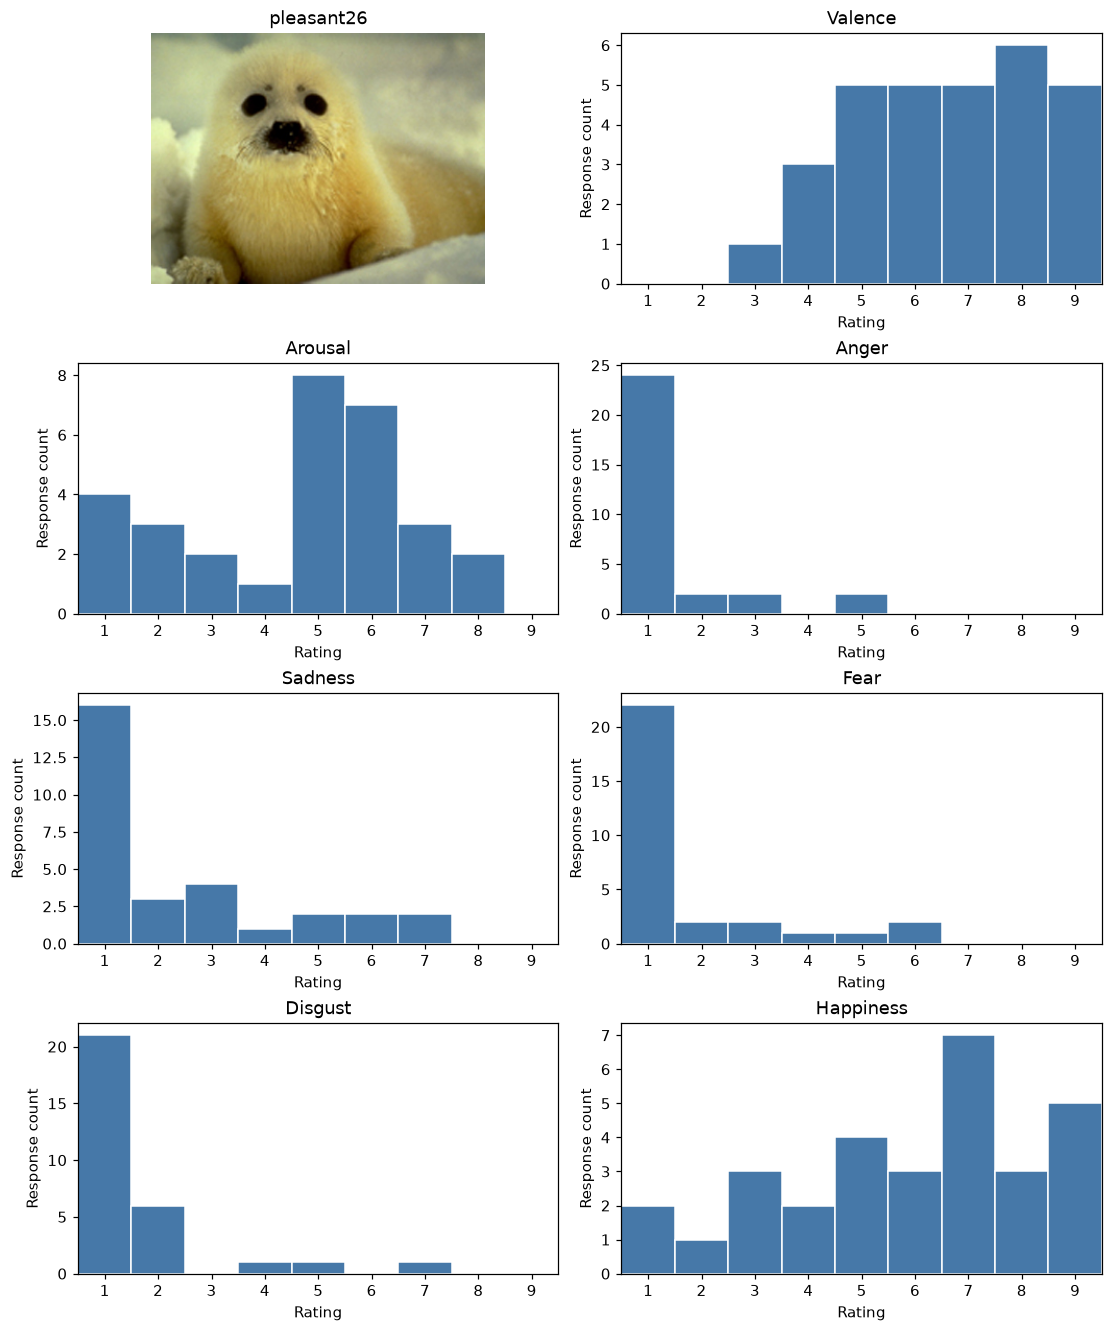

Mean Valence: 6.6000 (n=30)
Mean Arousal: 4.6333 (n=30)
Mean Anger: 1.4667 (n=30)
Mean Sadness: 2.4667 (n=30)
Mean Fear: 1.7667 (n=30)
Mean Disgust: 1.6333 (n=30)
Mean Happiness: 5.9000 (n=30)


In [4]:
#@title Inspect an image { display-mode: "form" }
Image_number = 1 #@param {type:"integer"}
im = image_at(Image_number)
responses = ratings[:, Image_number - 1, :]
fig, axes = plt.subplots(4, 2, figsize=(10, 12), constrained_layout=True)
axes = axes.ravel()
axes[0].imshow(im)
axes[0].set_title(names[Image_number - 1])
axes[0].axis("off")
for q, ax in enumerate(axes[1:]):
    values = responses[:, q]
    ax.hist(values[np.isfinite(values)], bins=np.arange(0.5, 10, 1), color="#4678a8", edgecolor="white")
    ax.set(title=questions[q], xlabel="Rating", ylabel="Response count", xlim=(0.5, 9.5))
    ax.set_xticks(range(1, 10))
plt.show()
for q, question in enumerate(questions):
    n = np.isfinite(responses[:, q]).sum()
    print(f"Mean {question}: {means[Image_number - 1, q]:.4f} (n={n})")

## Investigation 2 · The average hides the argument
Two pictures have almost the same average **valence** rating. Does that mean people responded to them in the same way?

**Predict:** Run once with **Reveal_histograms** unticked. Look at the pictures and their averages. Sketch the rating distributions you expect, or describe them in a sentence.

**Reveal:** Tick **Reveal_histograms** and run again. Taller bars represent more people giving that rating. Standard deviation summarizes spread: a larger value means ratings are more dispersed.

**Explain:** Which picture produced more agreement? Does a middle average mean everyone felt neutral? What information did the average hide?

These are separate samples of responses to each picture. A wider distribution shows disagreement, but does not establish why people disagreed or prove two distinct groups exist. Think about why these two images might have different distributions.

In [ ]:
#@title Similar averages, different responses { display-mode: "form" }
Reveal_histograms = False #@param {type:"boolean"}
pair_indices = [names.index("neutral3"), names.index("extreme53")]
pair_means = means[pair_indices, 0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for k, ax in enumerate(axes):
    ax.imshow(image_at(pair_indices[k] + 1)); ax.axis("off")
    ax.set_title(f"Picture {['A','B'][k]} · average valence {pair_means[k]:.2f}")
plt.show()
if not Reveal_histograms:
    print("Make your prediction before ticking Reveal_histograms and running again.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)
    pair_spreads = []
    for k, ax in enumerate(axes):
        values = ratings[:, pair_indices[k], 0]
        values = values[np.isfinite(values)]
        pair_spreads.append(float(np.std(values, ddof=1)))
        ax.hist(values, bins=np.arange(0.5, 10, 1), edgecolor="white", color="#4678a8")
        ax.set(title=f"Picture {['A','B'][k]} · n={len(values)} · SD={pair_spreads[-1]:.2f}",
               xlabel="Valence rating", ylabel="Response count", xlim=(0.5,9.5), xticks=range(1,10))
    plt.show()

## Part 2 · Do the questions overlap?
Some questions might capture similar aspects of emotion. A **correlation** describes how two ratings tend to move together:

- Near **+1**: high ratings on one tend to accompany high ratings on the other.
- Near **−1**: high ratings on one tend to accompany low ratings on the other.
- Near **0**: little linear relationship.

**Do this:** Click ▶ below. Find **Valence** and **Happiness** in the coloured grid. Their intersection shows the relationship between those questions. The colour key tells you how to read the colours. The diagonal is always 1 because each question is compared with itself.

**Try this:** Find a strongly positive pair, a negative pair, and a pair with a weak relationship.

**Discuss:** Which questions seem to overlap? Does a high correlation mean they measure exactly the same thing?

These correlations use individual people's responses. Only pairs where both answers are present are included. Your valence–happiness result should be approximately **0.8206 for PG** or **0.8356 for Full**.

Valence–happiness correlation: 0.8206


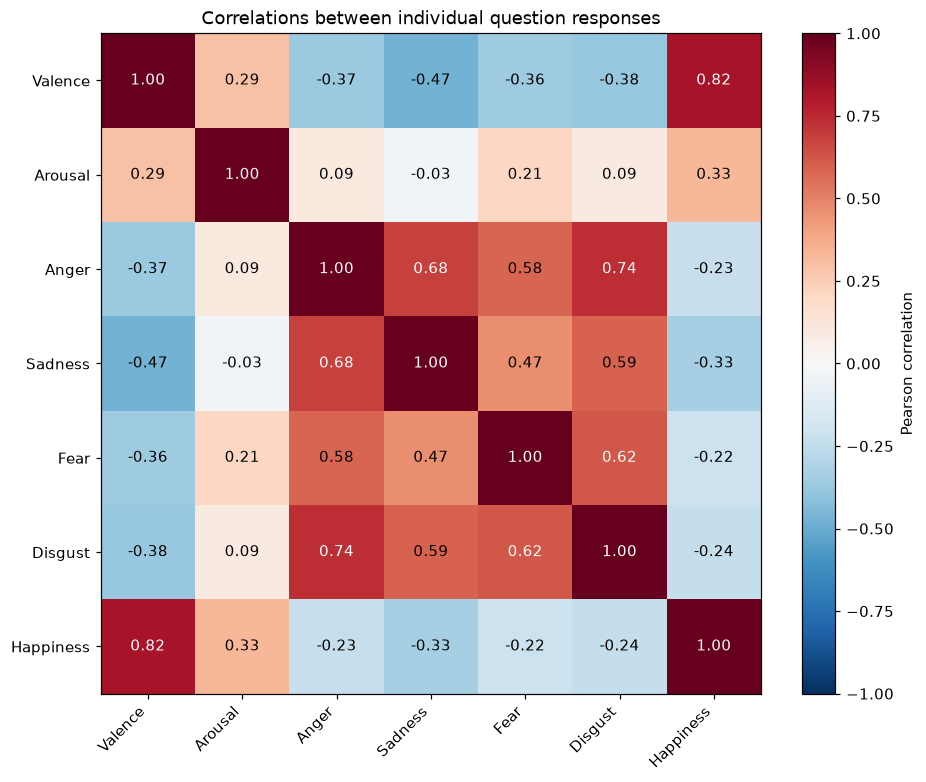

In [6]:
#@title Explore relationships between questions { display-mode: "form" }
flat_ratings = ratings.reshape(-1, len(questions))
question_correlations = np.empty((len(questions), len(questions)))
pair_counts = np.zeros_like(question_correlations, dtype=int)
for i in range(len(questions)):
    for j in range(len(questions)):
        valid = np.isfinite(flat_ratings[:, i]) & np.isfinite(flat_ratings[:, j])
        pair_counts[i, j] = valid.sum()
        question_correlations[i, j] = np.corrcoef(flat_ratings[valid, i], flat_ratings[valid, j])[0, 1]
print(f"Valence–happiness correlation: {question_correlations[0, 6]:.4f}")
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
heatmap = ax.imshow(question_correlations, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(7), questions, rotation=45, ha="right")
ax.set_yticks(range(7), questions)
for i in range(7):
    for j in range(7):
        value = question_correlations[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.6 else "black")
fig.colorbar(heatmap, ax=ax, label="Pearson correlation")
ax.set_title("Correlations between individual question responses")
plt.show()

## Part 3 · Turn the ratings into a map
Imagine each picture as a point whose position is determined by its ratings. A two-dimensional map can show two questions at a time.

**Do this:** Leave Valence and Happiness selected and click ▶. Each dot is one picture. Its horizontal and vertical positions show its average ratings on the two questions. What does the relationship between responses tell you about the two questions?

**Try this:** Compare Valence with Fear, then Arousal with Fear. Change the dropdowns and run the activity again each time.

**Discuss:** What does a dot near the top right mean? Which comparisons show a clear relationship, and which show more spread?

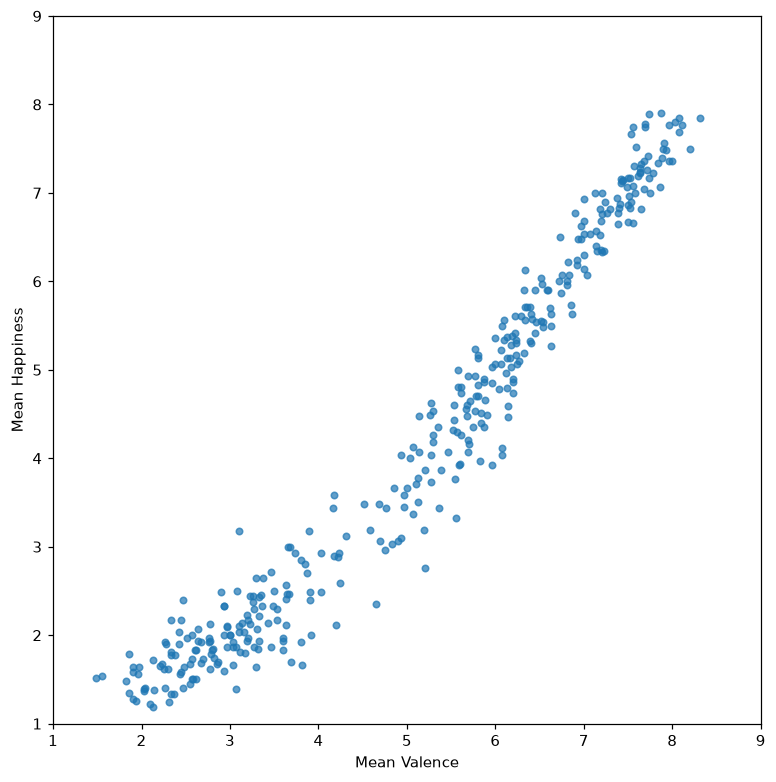

Correlation between image means: 0.9748


In [7]:
#@title Compare two questions { display-mode: "form" }
First_question = "Valence" #@param ["Valence", "Arousal", "Anger", "Sadness", "Fear", "Disgust", "Happiness"]
Second_question = "Happiness" #@param ["Valence", "Arousal", "Anger", "Sadness", "Fear", "Disgust", "Happiness"]
q1, q2 = questions.index(First_question), questions.index(Second_question)
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.scatter(means[:, q1], means[:, q2], s=18, alpha=0.7)
ax.set(xlabel=f"Mean {questions[q1]}", ylabel=f"Mean {questions[q2]}", xlim=(1, 9), ylim=(1, 9))
ax.set_aspect("equal", adjustable="box")
plt.show()
print(f"Correlation between image means: {np.corrcoef(means[:, q1], means[:, q2])[0, 1]:.4f}")

## Part 4A · Can we simplify the map?
Seven questions give us seven dimensions. If some questions overlap, we may be able to describe much of the variation with fewer dimensions.

### Think about a personality questionnaire
Imagine a personality questionnaire with 70 questions intended to measure seven broad personality traits. Why ask so many questions if we are interested in only seven traits? Several questions may capture different aspects of the same trait.

For example, someone who agrees with “I enjoy meeting new people” might also agree with “I like being the centre of attention” and disagree with “I prefer to stay quiet in social situations.” These answers may vary together across people. Rather than treating all three answers as unrelated dimensions, we could combine them into a score that summarizes their shared pattern. We might interpret that pattern as **extraversion**, then consider whether the other questions and further evidence support that interpretation.

**Principal component analysis (PCA)** helps us make this kind of simplification. It builds new scores from **weighted combinations of the original questions**. Questions contribute more or less strongly, and their contributions can point in opposite directions. A component is a combination of questions, rather than simply a label attached to a group of them.

The first component captures the most variation in the ratings. The second captures as much of the remaining variation as possible while being uncorrelated with the first. Later components continue this process. If a few components capture most of the variation, they offer a simpler description of the original responses. PCA does not assume that our hypothetical questionnaire will produce seven useful components just because we intended to measure seven traits.

### Apply the same idea to emotional ratings
Our emotion questions also overlap: for example, valence and happiness tend to move together. PCA can combine their information with the other questions to create a smaller set of useful dimensions. In the personality example, we compare people's questionnaire responses; here, we compare **pictures using their average ratings** on the seven emotion questions.

**Do this:** Click ▶ to calculate the components. The graph shows the percentage of variation captured by each one.

**Discuss:** How much does the first component capture? How much do the first three capture together? What information might we lose by using only two?

All questions retain their original rating scales. As with the personality example, naming a component is an interpretation to investigate. PCA summarizes patterns in this dataset; it does not by itself prove that particular psychological constructs exist.

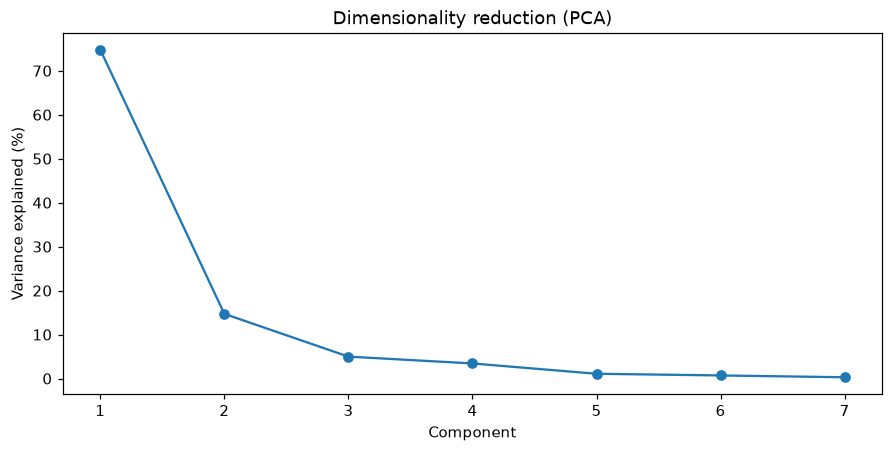

Variance explained (%): [74.79 14.71  4.99  3.43  1.09  0.7   0.29]
First three components: 94.49%


In [8]:
#@title Find the main dimensions { display-mode: "form" }
centered_means = means - means.mean(axis=0)
u, singular_values, vt = np.linalg.svd(centered_means, full_matrices=False)
COEFF = vt.T.copy()
SCORE = centered_means @ COEFF
# Make the largest absolute weight positive for a reproducible display convention.
# A component and its negative describe the same PCA solution.
for c in range(COEFF.shape[1]):
    pivot = np.argmax(np.abs(COEFF[:, c]))
    if COEFF[pivot, c] < 0:
        COEFF[:, c] *= -1
        SCORE[:, c] *= -1
LATENT = singular_values ** 2 / (len(means) - 1)
explained_percent = 100 * LATENT / LATENT.sum()
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(range(1, 8), explained_percent, "o-")
ax.set(xlabel="Component", ylabel="Variance explained (%)", title="Dimensionality reduction (PCA)", xticks=range(1, 8))
plt.show()
print("Variance explained (%):", np.round(explained_percent, 2))
print(f"First three components: {explained_percent[:3].sum():.2f}%")


def check_component(number):
    if not 1 <= number <= COEFF.shape[1]:
        raise ValueError(f"Component number must be between 1 and {COEFF.shape[1]}.")
    return number - 1

## Part 4B · What might the components mean?
Return to the personality example: a component with strong contributions from questions about enjoying company might suggest extraversion. To judge that interpretation, we would inspect which questions contributed and in which direction.

We now do the same for emotional ratings. Each component combines the seven questions using **weights**. A taller bar, in either direction, means that question contributes more strongly. Opposite signs indicate questions pointing in opposite directions along the component.

**Do this:** Select component 1 and click ▶. Identify the questions with the largest positive and negative weights. Use this pattern to give your best interpretation of what the component represents.

**Try this:** Repeat for components 2 and 3.

**Discuss:** What name would you give each component? Which weights support your interpretation? Are there questions that make your interpretation less clear?

**Note 1:** Not every component has a clear psychological interpretation. Later components explain less variation and may be harder to interpret, although a smaller component can still capture a meaningful pattern.

**Note 2:** A component's direction is arbitrary. Reversing all its weights and picture positions produces the same underlying solution.

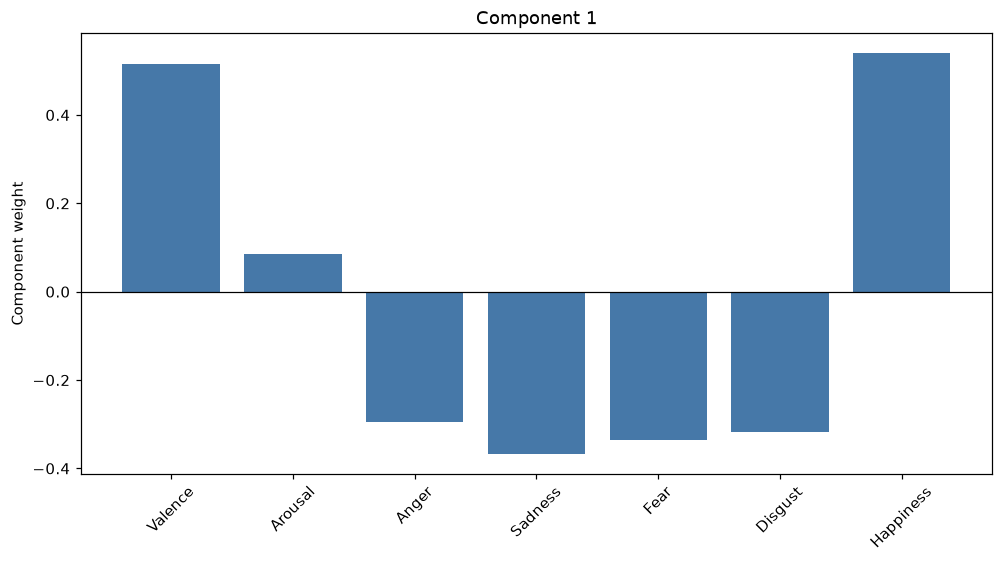

In [9]:
#@title Inspect component weights { display-mode: "form" }
Component = 1 #@param [1, 2, 3, 4, 5, 6, 7] {type:"raw"}
c = check_component(Component)
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.bar(questions, COEFF[:, c], color="#4678a8")
ax.axhline(0, color="black", linewidth=0.8)
ax.tick_params(axis="x", rotation=45)
ax.set(ylabel="Component weight", title=f"Component {Component}")
plt.show()

## Investigation 3 · Predict a picture's position
In Investigation 1, you predicted a picture's average ratings on seven questions. Now predict where a picture belongs on **one component that combines those questions**.

**Read the weights:** Higher-than-average ratings on questions with positive weights push a picture towards a positive component score. Higher-than-average ratings on questions with negative weights push it towards a negative score. Lower-than-average ratings push in the opposite direction. Larger weights have a stronger effect.

For example, if Q1 (**Valence**) and Q7 (**Happiness**) have large positive weights, a picture you expect people to rate as more pleasant and happy tends towards the positive end. Check the other weights too: all seven ratings contribute. Think back to how you predicted the individual questions, and use that same reasoning here.

**Predict:** Choose a component and picture below, then click ▶. Inspect the picture and weights. Give the component a name, then move the slider to your predicted position. This is an **approximate prediction**: aim for the negative end, near the middle, or the positive end. You are not expected to calculate an exact PCA score. Zero represents the average component score across this dataset, not an absence of emotion.

**Reveal:** Click **Reveal position** to compare your prediction with the picture's actual position. Do the weights explain why it lies there? A small difference from your estimate is not a mistake to be marked; use the comparison to examine your interpretation.

**Challenge:** Try Pictures A, B and C, then components 2 and 3. Which predictions fit your interpretation? Which are less clear? Would you change the component name?

The direction is arbitrary, but the displayed weights tell you how to read this solution. Reversing every weight would reverse the picture positions too, preserving the emotional pattern. These pictures were included in the PCA fit; this is an interpretation exercise, not a test on a separate dataset. Changing the component or picture and running again starts a fresh prediction.

In [ ]:
#@title Predict one picture on one component { display-mode: "form" }
Component = 1 #@param [1,2,3,4,5,6,7] {type:"raw"}
Example_picture = "Picture A" #@param ["Picture A","Picture B","Picture C"]
import ipywidgets as widgets
from IPython.display import display, clear_output
component_index = check_component(Component)
example_names = {"Picture A":"neutral49", "Picture B":"fear25", "Picture C":"extreme20"}
example_index = names.index(example_names[Example_picture])
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
axes[0].imshow(image_at(example_index + 1)); axes[0].axis("off"); axes[0].set_title(Example_picture)
axes[1].bar(questions, COEFF[:, component_index]); axes[1].axhline(0, color="black", linewidth=.8)
axes[1].tick_params(axis="x", rotation=60)
axes[1].set(title=f"Component {Component}: question weights", ylabel="Question weight")
plt.show()
component_name_input = widgets.Text(description="Your name:", placeholder="What might this component represent?", layout=widgets.Layout(width="95%"))
position_limit = max(float(np.max(np.abs(SCORE[:, component_index]))), .1) * 1.1
position_prediction = widgets.FloatSlider(value=0, min=-position_limit, max=position_limit,
    step=position_limit/100, description="Position:", readout=False, continuous_update=False,
    layout=widgets.Layout(width="95%"))
position_confirm = widgets.Checkbox(value=False, description="I have chosen my approximate prediction", indent=False)
position_reveal_button = widgets.Button(description="Reveal position", button_style="info")
position_output = widgets.Output()
def reveal_component_position(_):
    with position_output:
        clear_output(wait=True)
        if not component_name_input.value.strip() or not position_confirm.value:
            print("Name the component and confirm your approximate prediction first.")
            return
        actual_position = float(SCORE[example_index, component_index])
        fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
        for j, (label, score, color) in enumerate([
            ("Your prediction", position_prediction.value, "#2878a0"),
            (Example_picture + " · actual", actual_position, "#c76035")]):
            ax.scatter([score], [0], s=120, color=color, zorder=3)
            ax.annotate(label, (score, 0), xytext=(0, 22 if j == 0 else -35),
                        textcoords="offset points", ha="center", color=color)
        ax.axhline(0, color="gray", linewidth=1); ax.axvline(0, color="gray", linestyle=":", linewidth=.8)
        ax.set(xlim=(-position_limit, position_limit), ylim=(-1, 1), yticks=[],
               xlabel=f"Component {Component} · {component_name_input.value.strip()}",
               title="Does the position support your interpretation?")
        for side in ["left", "right", "top"]: ax.spines[side].set_visible(False)
        plt.show()
        print("Use the weights to explain the position. This is an approximate comparison, not an exact-score test.")
        print("Which of your expected question ratings would push this picture towards each end?")
display(widgets.VBox([component_name_input,
    widgets.HTML("<b>Negative component score ← &nbsp; 0: dataset average &nbsp; → Positive component score</b><br>Move the slider to an approximate position; its range covers this dataset's scores."),
    position_prediction, position_confirm, position_reveal_button, position_output]))
position_reveal_button.on_click(reveal_component_position)


## Part 5A · Explore the emotional space
We can now position pictures using their values on the new components.

**Do this:** Start with components 1 and 2 and click ▶. Each label identifies a picture. Its position shows its values on those components. Use the weights from Part 4B to interpret the axes.

**Try this:** Compare components 1 and 3, then 2 and 3. Look for groups of similar pictures.

**Discuss:** Which categories appear close together? Which are separated? How does your interpretation change between maps?

To reduce crowding, the default shows every third picture. Choose **All pictures** for the complete set or **Every sixth picture** for a sparser view. Distances in this view reflect only the two selected components.

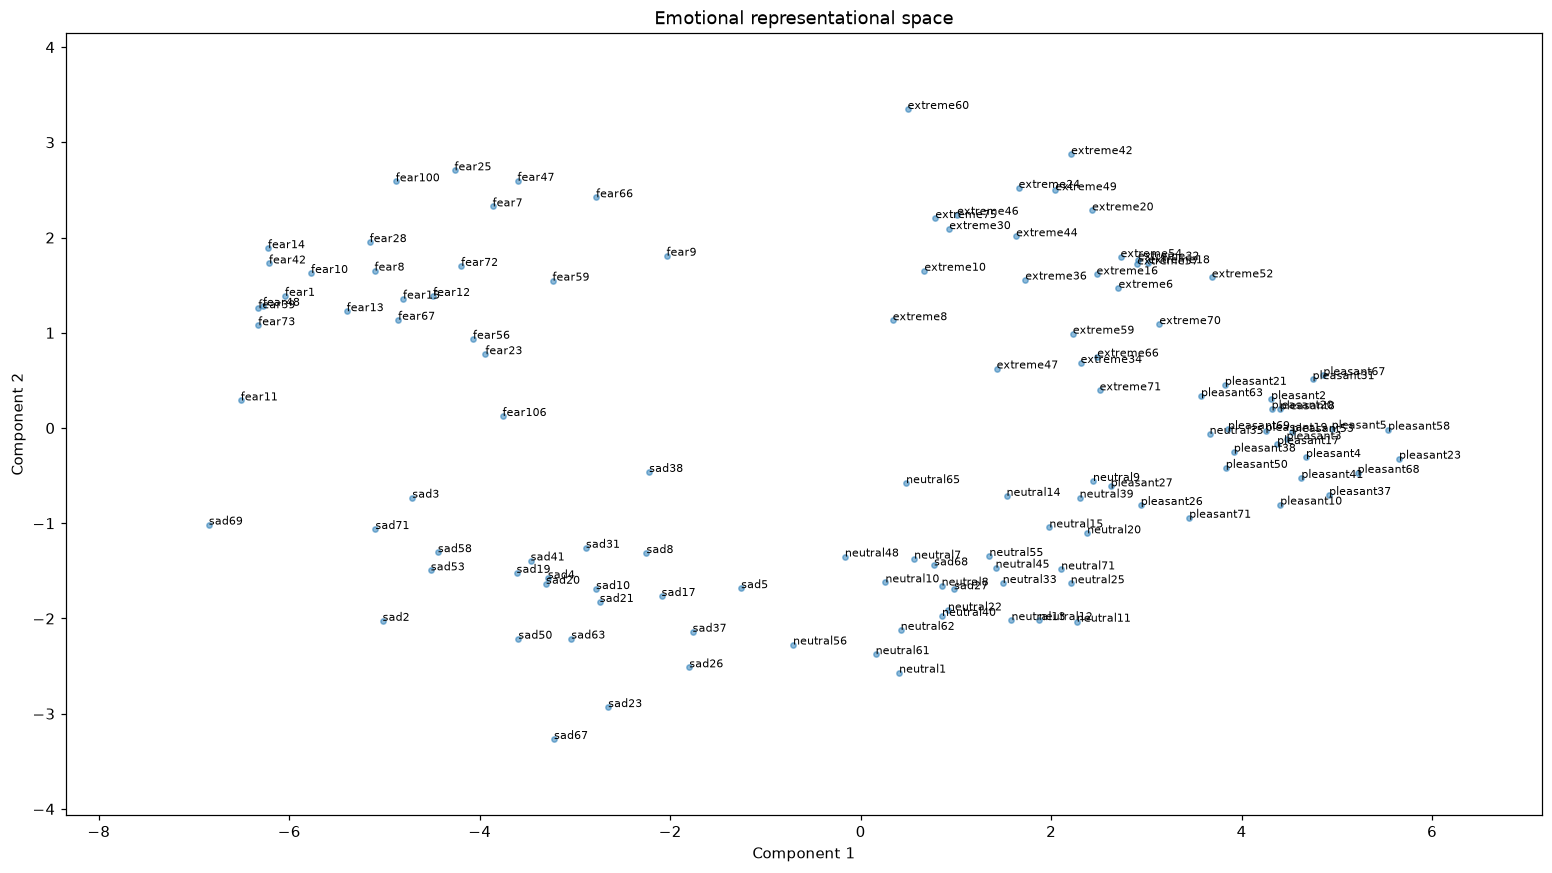

In [11]:
#@title Plot the space with text labels { display-mode: "form" }
Horizontal_component = 1 #@param [1, 2, 3, 4, 5, 6, 7] {type:"raw"}
Vertical_component = 2 #@param [1, 2, 3, 4, 5, 6, 7] {type:"raw"}
Pictures_to_show = "Every third picture" #@param ["All pictures", "Every third picture", "Every sixth picture"]
LABEL_STRIDE = {"All pictures": 1, "Every third picture": 3, "Every sixth picture": 6}[Pictures_to_show]
c1, c2 = check_component(Horizontal_component), check_component(Vertical_component)
if Horizontal_component == Vertical_component or LABEL_STRIDE < 1:
    raise ValueError("Choose different components and a positive stride.")
indices = np.arange(0, len(names), LABEL_STRIDE)
fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
ax.scatter(SCORE[indices, c1], SCORE[indices, c2], s=12, alpha=0.5)
for i in indices:
    ax.annotate(names[i], (SCORE[i, c1], SCORE[i, c2]), fontsize=7)
ax.set(xlabel=f"Component {Horizontal_component}", ylabel=f"Component {Vertical_component}", title="Emotional representational space")
ax.set_aspect("equal", adjustable="box")
ax.margins(0.12)
plt.show()

## Part 5B · See the pictures in the space
**Do this:** Start with components 1 and 2 and click ▶. The pictures now appear at their positions in the same kind of map.

**Try this:** Explore components 1 and 3 or 2 and 3. If pictures overlap too much, show fewer pictures or reduce their displayed size.

**Discuss:** Does the arrangement support the names you gave the components? Find an image that fits your interpretation and one that challenges it.

Picture size is only a display setting. It does not represent the strength of an emotion. Nearby pictures have similar values on these two components; they may differ on other components.

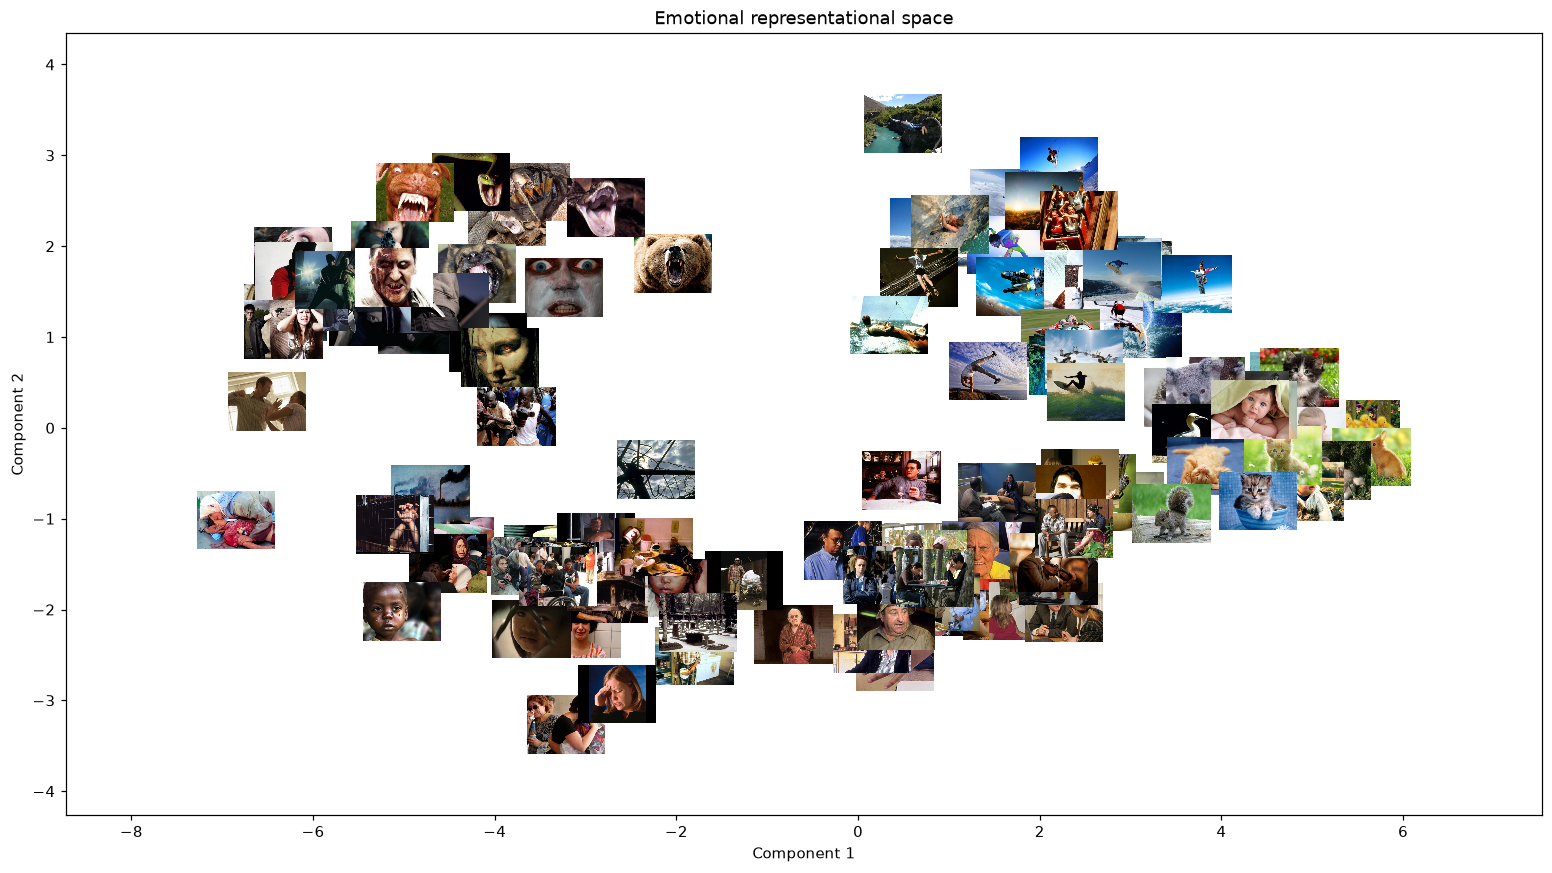

In [12]:
#@title Plot the space with images { display-mode: "form" }
Horizontal_component = 1 #@param [1, 2, 3, 4, 5, 6, 7] {type:"raw"}
Vertical_component = 2 #@param [1, 2, 3, 4, 5, 6, 7] {type:"raw"}
Pictures_to_show = "Every third picture" #@param ["All pictures", "Every third picture", "Every sixth picture"]
IMAGE_STRIDE = {"All pictures": 1, "Every third picture": 3, "Every sixth picture": 6}[Pictures_to_show]
Picture_size = 0.16 #@param {type:"slider", min:0.05, max:0.30, step:0.01}
c1, c2 = check_component(Horizontal_component), check_component(Vertical_component)
if Horizontal_component == Vertical_component or IMAGE_STRIDE < 1 or not 0 < Picture_size <= 1:
    raise ValueError("Choose different components, a positive stride, and zoom in (0, 1].")
indices = np.arange(0, len(names), IMAGE_STRIDE)
fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)
ax.scatter(SCORE[indices, c1], SCORE[indices, c2], s=0)
for i in indices:
    thumbnail = OffsetImage(image_at(int(i) + 1), zoom=Picture_size)
    ax.add_artist(AnnotationBbox(thumbnail, (SCORE[i, c1], SCORE[i, c2]), frameon=False))
ax.set(xlabel=f"Component {Horizontal_component}", ylabel=f"Component {Vertical_component}", title="Emotional representational space")
ax.set_aspect("equal", adjustable="box")
ax.margins(0.15)
plt.show()

## Investigation 4 · Does the map depend on the pictures we choose?
Would PCA find the same patterns if we had only used pleasant and neutral pictures?

**Predict:** In your notes, predict which questions will become more or less important and whether the first component will explain more or less variation.

**Test:** Leave only Pleasant and Neutral ticked and run the activity. Then add other categories and run again. Full offers two extra categories; they are unavailable in PG. Category names describe how stimuli were grouped, not a diagnosis of anyone's response.

The left map uses the original PCA; the right map uses PCA fitted to your selected pictures. **Both maps show the same selected pictures**, with common limits and equal axis scaling. The accompanying bars compare question weights. This lets you separate changing the sample from merely changing which points are drawn.

Components are matched to the original ones by their question weights and sign-aligned for comparison. A matched component may no longer have the same variance rank. Low similarity means you should be cautious about treating it as the same dimension. Matching every component does not guarantee equivalent psychological meaning.

**Explain:** Which changes did you predict correctly? Does a high explained-variance percentage alone make a component meaningful? What does this exercise suggest about generalizing beyond the selected images?

In [ ]:
#@title Rebuild the map with a different image sample { display-mode: "form" }
Pleasant = True #@param {type:"boolean"}
Neutral = True #@param {type:"boolean"}
Fear = False #@param {type:"boolean"}
Sadness = False #@param {type:"boolean"}
Extreme = False #@param {type:"boolean"}
Disgust = False #@param {type:"boolean"}
Erotic = False #@param {type:"boolean"}
Horizontal_component = 1 #@param [1,2,3,4,5,6,7] {type:"raw"}
Vertical_component = 2 #@param [1,2,3,4,5,6,7] {type:"raw"}
category_choices = {"pleasant":Pleasant,"neutral":Neutral,"fear":Fear,"sad":Sadness,
                    "extreme":Extreme,"disgust":Disgust,"erotic":Erotic}
image_categories = np.asarray([re.sub(r"\d+$", "", name) for name in names])
available_categories = set(image_categories)
requested_categories = [key for key,value in category_choices.items() if value]
unavailable = set(requested_categories) - available_categories
subset_indices = np.flatnonzero(np.isin(image_categories, requested_categories))
subset_weights_aligned = None
if unavailable:
    print("Unavailable in this dataset:", ", ".join(sorted(unavailable)), ". Untick these or choose Full in setup.")
elif len(subset_indices) < 8:
    print("Select categories containing at least eight pictures.")
elif Horizontal_component == Vertical_component:
    print("Choose two different components.")
else:
    c1,c2 = check_component(Horizontal_component),check_component(Vertical_component)
    subset_center, subset_weights, subset_scores, subset_latent = fit_pca(means[subset_indices])
    subset_weights_aligned, subset_scores_aligned, subset_order, subset_similarity = align_components(COEFF,subset_weights,subset_scores)
    subset_percent = 100 * subset_latent / subset_latent.sum()
    rows = []
    for c in [c1,c2]:
        rank = int(subset_order[c])+1
        rows.append([f"Original component {c+1}",f"{explained_percent[c]:.1f}%",f"{rank}",
                     f"{subset_percent[rank-1]:.1f}%",f"{subset_similarity[c]:.2f}"])
    show_table(["Matched axis","Original variance","Subset rank","Subset variance","Weight similarity (0–1)"],rows)
    print(f"Selected {len(subset_indices)} of {len(names)} pictures.")
    if min(subset_similarity[[c1,c2]]) < .8:
        print("At least one match is weak. Inspect its question weights before treating it as the same construct.")
    fig,axes=plt.subplots(1,2,figsize=(13,6),constrained_layout=True)
    plotted = [SCORE[subset_indices],subset_scores_aligned]
    colors=np.asarray([sorted(available_categories).index(category) for category in image_categories[subset_indices]])
    x_values=np.concatenate([values[:,c1] for values in plotted]); y_values=np.concatenate([values[:,c2] for values in plotted])
    xpad=max(np.ptp(x_values)*.1,.2);ypad=max(np.ptp(y_values)*.1,.2)
    for ax,values,title in zip(axes,plotted,["Original PCA · selected pictures","Refitted PCA · same pictures"]):
        for category in sorted(set(image_categories[subset_indices])):
            chosen=image_categories[subset_indices]==category
            color_index=sorted(available_categories).index(category)
            ax.scatter(values[chosen,c1],values[chosen,c2],s=18,alpha=.65,
                       color=plt.get_cmap("tab10")(color_index),label=category.capitalize())
        ax.axhline(0,color="gray",linewidth=.5);ax.axvline(0,color="gray",linewidth=.5)
        ax.set(title=title,xlabel=f"Matched component {c1+1}",ylabel=f"Matched component {c2+1}",
               xlim=(x_values.min()-xpad,x_values.max()+xpad),ylim=(y_values.min()-ypad,y_values.max()+ypad))
        ax.set_aspect("equal",adjustable="box");ax.legend(fontsize=8)
    plt.show()
    fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
    positions=np.arange(7)
    for ax,c in zip(axes,[c1,c2]):
        ax.bar(positions-.18,COEFF[:,c],width=.36,label="Original PCA")
        ax.bar(positions+.18,subset_weights_aligned[:,c],width=.36,label="Refitted PCA")
        ax.set_xticks(positions,questions,rotation=50,ha="right")
        ax.axhline(0,color="black",linewidth=.8);ax.set(title=f"Question weights · matched component {c+1}",ylabel="Weight")
        ax.legend()
    plt.show()

## Optional finale · You, the participants, and AI
Return to your six forecasts. Could an AI predict the participant averages more closely? Before trying it, write down which pictures or questions you expect AI to find difficult.

### 1 · Prepare the same pictures
Run **Prepare the AI comparison** below. It creates a labelled contact sheet and a standard prompt. Click the download buttons. Downloading does not send anything to an AI service.

### 2 · Ask for predictions
In your own ChatGPT conversation, attach the contact sheet and paste the standard prompt. Do not give it the participant results or your predictions. Ask it to return predictions for the **average human response**, not to report its own feelings. You choose whether to upload the images to that service.

[Official instructions for image inputs](https://learn.chatgpt.com/docs/image-inputs).

If the model cannot inspect an image or declines the task, record that limitation rather than inventing a rating. You can skip this activity and still complete the tutorial. Use the same prompt across the class and record the displayed model name. A repeat in a fresh chat can explore consistency, but keep the first result rather than choosing whichever looks best.

### 3 · Compare and explain
Paste only the JSON response into **Compare AI predictions** below, enter the model name, and click **Compare predictions**. Seven ratings are expected in this order: Valence, Arousal, Anger, Sadness, Fear, Disgust, Happiness.

The plots compare you, AI, and participants. Mean absolute difference is the average distance from the participant mean, in rating points; smaller is closer for these examples. Participants' averages are a reference, not a universal emotional truth.

**Discuss:** Where did AI agree with people? Where did it miss? Did its advantage depend on the question? What might explain a confident but inaccurate prediction? Six selected pictures are an exploratory comparison, not evidence about AI performance in general or evidence that AI experiences emotions.

In [ ]:
#@title Prepare the AI comparison { display-mode: "form" }
# Save a labelled sheet without including human/student ratings.
from PIL import ImageDraw
sheet = Image.new("RGB", (960, 548), "white")
for i,index in enumerate(challenge_indices):
    x,y=(i%3)*320,(i//3)*274
    sheet.paste(Image.fromarray(image_at(index+1)),(x,y+34))
    ImageDraw.Draw(sheet).text((12+x,10+y),challenge_labels[i],fill="black")
contact_sheet_path=Path("six_pictures_for_ai.png");sheet.save(contact_sheet_path)
standard_ai_prompt = """The attached pictures are labelled Picture 1 through Picture 6. Predict the average human survey response to each picture on the seven scales below. Predict group averages, not your own emotions. Use only the visual content of these images; do not look up IAPS identifiers or published norms. If you cannot inspect an image or cannot provide a prediction, say so instead of inventing values.

Give each rating as a number from 1 to 9 (decimals are allowed), in this exact order:
1. Valence: very unhappy (1) to very happy (9).
2. Arousal: not at all aroused (1) to very aroused (9).
3. Anger: no anger (1) to very much anger (9).
4. Sadness: no sadness (1) to very much sadness (9).
5. Fear: no fear (1) to very much fear (9).
6. Disgust: no disgust (1) to very much disgust (9).
7. Happiness: no happiness (1) to very much happiness (9).

Return only a JSON object with exactly the keys "Picture 1", "Picture 2", "Picture 3", "Picture 4", "Picture 5", and "Picture 6". Each value must be a list of seven numeric predictions in the stated order. Do not include explanatory text or markdown fences. If you cannot complete all six, explain the limitation instead of returning a partial or fabricated object."""
ai_prompt_path=Path("ai_comparison_prompt.txt");ai_prompt_path.write_text(standard_ai_prompt)
print(standard_ai_prompt)
sheet_button=widgets.Button(description="Download contact sheet",layout=widgets.Layout(width="220px"))
prompt_button=widgets.Button(description="Download prompt",layout=widgets.Layout(width="180px"))
sheet_button.on_click(lambda button: download_file(contact_sheet_path))
prompt_button.on_click(lambda button: download_file(ai_prompt_path))
display(widgets.VBox([sheet_button,prompt_button]))

In [ ]:
#@title Compare AI predictions { display-mode: "form" }
if "ai_comparison_panel" in globals():
    ai_comparison_panel.close()
ai_response_input=widgets.Textarea(placeholder='Paste the complete JSON response here',layout=widgets.Layout(width="100%",height="180px"))
ai_model_input=widgets.Text(description="Model:",placeholder="Displayed model name")
ai_compare_button=widgets.Button(description="Compare predictions",button_style="primary",layout=widgets.Layout(width="200px"))
ai_export_button=widgets.Button(description="Download comparison",layout=widgets.Layout(width="210px"))
ai_comparison_output=widgets.Output()

def compare_ai(button=None):
    global ai_predictions,ai_run_metadata,ai_comparison_snapshot
    ai_predictions=None
    ai_comparison_snapshot=None
    with ai_comparison_output:
        ai_comparison_output.clear_output()
        if set(student_predictions)!=set(challenge_labels):
            print("Save your six predictions in Investigation 1 first, or restore your backup.");return
        try:
            values=decode_predictions(ai_response_input.value)
            if not ai_model_input.value.strip():
                raise ValueError("Enter the displayed model name.")
        except ValueError as exc:
            print(str(exc));return
        ai_predictions=values
        ai_run_metadata={"model":ai_model_input.value.strip()}
        your_values=np.asarray([student_predictions[label] for label in challenge_labels])
        ai_values=np.asarray([ai_predictions[label] for label in challenge_labels])
        human=comparison_plot(your_values,ai_values)
        ai_comparison_snapshot={"dataset":DATASET,"picture_sources":dict(zip(challenge_labels,challenge_names)),
            "questions":questions[:],"student_predictions":json.loads(json.dumps(student_predictions)),
            "ai_predictions":json.loads(json.dumps(ai_predictions)),"participant_means":human.tolist(),
            "ai_run":ai_run_metadata.copy(),"prompt":standard_ai_prompt}
        student_errors=np.abs(your_values-human);ai_errors=np.abs(ai_values-human)
        show_table(["Question","Your mean absolute difference","AI mean absolute difference"],
            [[q,f"{student_errors[:,j].mean():.2f}",f"{ai_errors[:,j].mean():.2f}"] for j,q in enumerate(questions)])
        show_table(["Picture","Your mean absolute difference","AI mean absolute difference"],
            [[label,f"{student_errors[i].mean():.2f}",f"{ai_errors[i].mean():.2f}"] for i,label in enumerate(challenge_labels)])
        print(f"Overall average difference: you {student_errors.mean():.2f}; AI {ai_errors.mean():.2f} rating points.")
        print("An exploratory comparison of six examples; these differences do not establish general performance.")

def export_ai_comparison(button=None):
    with ai_comparison_output:
        if ai_comparison_snapshot is None:
            print("Complete a valid comparison before downloading it.");return
        path=Path("my_ai_comparison.json")
        path.write_text(json.dumps(ai_comparison_snapshot,indent=2))
        download_file(path)

ai_compare_button.on_click(compare_ai)
ai_export_button.on_click(export_ai_comparison)
ai_comparison_panel=widgets.VBox([ai_response_input,ai_model_input,ai_compare_button,ai_export_button,ai_comparison_output])
display(ai_comparison_panel)

## Optional · Check the calculations
Click ▶ if you would like to run the built-in numerical checks. You do not need to inspect or understand the code to complete the tutorial. These checks verify the calculations, rather than the psychological interpretation.

In [16]:
#@title Check the calculations (optional) { display-mode: "form" }
assert COEFF.shape == (7, 7)
assert SCORE.shape == (len(names), 7)
assert np.isfinite(question_correlations).all()
assert np.allclose(question_correlations, question_correlations.T)
assert np.allclose(np.diag(question_correlations), 1)
assert np.allclose(COEFF.T @ COEFF, np.eye(7), atol=1e-10)
assert np.allclose(SCORE @ COEFF.T, centered_means, atol=1e-10)
assert np.isclose(explained_percent.sum(), 100)
assert np.allclose(np.cov(SCORE, rowvar=False), np.diag(LATENT), atol=1e-10)
print("All numerical consistency checks passed.")

All numerical consistency checks passed.


## Bring it together
In your notes, answer these questions:

1. Which survey questions appear to measure overlapping aspects of emotion? Use one result as evidence.
2. How many components would you retain, and why?
3. Give an interpretation of one component, supported by its question weights and the positions of pictures.
4. What might averaging across people hide?
5. What further evidence would help you test your interpretation?

You have built a representational space from people's emotional ratings. Save your notebook copy if you want to keep your results and notes.

6. Explain how two similar averages can conceal different response distributions.
7. How did changing the stimulus sample affect the interpretation of your components?
8. If you tried the AI activity, what did the comparison establish, and what did it leave unanswered?